In [ ]:
%pip install torch torchvision torchaudio datasets accelerate huggingface_hub[hf_transfer] torch_xla "cleanlab[datalab]" -q

%pip uninstall -y tensorflow && pip install tensorflow-cpu

%pip install symspellpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 7.0 MB/s eta 0:00:00
Found existing installation: tensorflow 2.17.0
Uninstalling tensorflow-2.17.0:
  Successfully uninstalled tensorflow-2.17.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.2/221.2 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 kB 13.6 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import math
import copy

import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.tokenize import sent_tokenize, word_tokenize
import nltk
nltk.download('punkt')

# Import tqdm
from tqdm import tqdm

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


# Load Data

In [ ]:
from datasets import load_dataset

ds = load_dataset("scillm/scientific_papers-archive")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/8.27k [00:00<?, ?B/s]

scientific_papers_arxiv_train.jsonl:   0%|          | 0.00/4.65G [00:00<?, ?B/s]

scientific_papers_pubmed_train.jsonl:   0%|          | 0.00/2.89G [00:00<?, ?B/s]

scientific_papers_arxiv_val.jsonl:   0%|          | 0.00/141M [00:00<?, ?B/s]

...

scientific_papers_arxiv_test.jsonl:   0%|          | 0.00/141M [00:00<?, ?B/s]

scientific_papers_pubmed_test.jsonl:   0%|          | 0.00/164M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [ ]:
ds_train = ds['train'].select(range(2000))
ds_val = ds['validation'].select(range(200))
ds_test = ds['test'].select(range(200))
ds_train

Dataset({
    features: ['id', 'input', 'output'],
    num_rows: 2000
})

In [ ]:
for example in ds_train:
    print(example)
    break

{'id': 0, 'input': 'Suppose that you have an abstract for a scientific paper:    additive models play an important role in semiparametric statistics . \n this paper gives learning rates for regularized kernel based methods for additive models . \n these learning rates compare favourably in particular in high dimensions to recent results on optimal learning rates for purely nonparametric regularized kernel based quantile regression using the gaussian radial basis function kernel , provided the assumption of an additive model is valid . \n additionally , a concrete example is presented to show that a gaussian function depending only on one variable lies in a reproducing kernel hilbert space generated by an additive gaussian kernel , but does not belong to the reproducing kernel hilbert space generated by the multivariate gaussian kernel of the same variance .    * \n key words and phrases . * additive model , kernel , quantile regression , semiparametric , rate of convergence , support v

# Data Cleaning

The dataset chosen for the final project contains several anomalies that require preprocessing. There are numerous occurrences of extra
spaces, both within sentences and around punctuation. Additionally, placeholder tokens such as @xcite, @xmathO, and more are used to
represent citations and mathematical formulas, though many other citations and formulas are not replaced with placeholders, creating
inconsistencies. Punctuation formatting is also problematic, with excess spaces appearing before or after symbols like periods and commas
(eg , ' . • and ' , v). There are also redundant punctuation marks, such as multiple commas or ellipses (e g
o, ' and' Furthermore, the
dataset contains numerous extra newlines that disrupt the text flow.

## SymSpell

In [ ]:
# Clone the SymSpell dictionary repository from GitHub
!git clone https://github.com/mammothb/symspellpy.git

# Path to the dictionary file inside the cloned repository
dictionary_path = "/content/symspellpy/symspellpy/frequency_dictionary_en_82_765.txt"

import re
from symspellpy.symspellpy import SymSpell, Verbosity

# Initialize SymSpell
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)

# Load the dictionary
sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)

# Function to correct text using SymSpell
def correct_text_with_symspell(text):
    corrected_text = []
    for word in text.split():
        suggestions = sym_spell.lookup(word, Verbosity.CLOSEST, max_edit_distance=2)
        if suggestions:
            corrected_text.append(suggestions[0].term)  # Use the best match
        else:
            corrected_text.append(word)  # If no suggestions, keep original word
    return ' '.join(corrected_text)

# Apply SymSpell correction to the dataset (no additional cleaning)
cleaned_ds_train = ds_train.map(lambda example: {
    'input': correct_text_with_symspell(example['input']),
    'output': correct_text_with_symspell(example['output']),
})
cleaned_ds_val = ds_val.map(lambda example: {
    'input': correct_text_with_symspell(example['input']),
    'output': correct_text_with_symspell(example['output']),
})
cleaned_ds_test = ds_test.map(lambda example: {
    'input': correct_text_with_symspell(example['input']),
    'output': correct_text_with_symspell(example['output']),
})

# View corrected data
print(cleaned_ds_train[:100])

Cloning into 'symspellpy'...
remote: Enumerating objects: 1440, done.
remote: Counting objects: 100% (408/408), done.
remote: Compressing objects: 100% (203/203), done.
remote: Total 1440 (delta 279), reused 276 (delta 203), pack-reused 1032 (from 1)
Receiving objects: 100% (1440/1440), 5.96 MiB | 15.30 MiB/s, done.
Resolving deltas: 100% (900/900), done.


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

{'id': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99], 'input': ['suppose that you have an abstract for a scientific paper additive models play an important role in semiparametric statistics a this paper gives learning rates for regularized kernel based methods for additive models a these learning rates compare favourably in particular in high dimensions to recent results on optimal learning rates for purely nonparametric regularized kernel based quartile regression using the gaussian radial basis function kernel a provided the assumption of an additive model is valid a additionally a a concrete example is presented to show that a gaussian function

## Clean whitespaces and punctuation

In [ ]:
import re


def clean_text(text):
    # Lowercase the text
    text = text.lower()

    # Remove citation placeholders like @xcite, @xmath0, etc.
    text = re.sub(r'@\s*\w+', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove LaTeX-style commands (like \alpha, \beta, etc.) and formulas
    text = re.sub(r'\\\[.*?\\\]|\\\(.*?\\\)|\\{.*?\\}|\\[a-zA-Z]+(\{.*?\})*', '', text)
    text = re.sub(r'\\[a-zA-Z]+(\{.*?\})*', '', text)  # Remove LaTeX commands
    text = re.sub(r'\\\[.*?\\\]', '', text)  # Remove block LaTeX formulas
    text = re.sub(r'\\\(.*?\\\)', '', text)  # Remove inline LaTeX formulas
    text = re.sub(r'[\{\}\[\]\(\)]', '', text)  # Remove curly braces and parentheses
    text = re.sub(r'\\[ ]*', '', text)  # Remove backslashes and spaces after them
    text = re.sub(r'[ ]*\\[ ]*', ' ', text)  # Remove standalone backslashes
    text = re.sub(r'([.]{2,}|[,]{2,}|[\?]{2,}|[!]{2,}|[:]{2,}|[;]{2,}|[\/]{2,})', r'\1', text)  # Clean up repeated punctuation

    # Remove specific unwanted terms
    text = re.sub(r'\{\\.*?\\}', '', text)  # Remove curly brace structures with backslashes

    # Remove special characters like '*', extra newlines, or multiple spaces
    text = text.replace('*', '')
    text = text.replace('_', '-')
    text = text.replace(' . ', '. ')
    text = text.replace(' , ', ', ')
    text = text.replace(' ( ', ' (')
    text = text.replace(' ) ', ') ')
    text = text.replace('`', "'")
    text = text.replace('\'\'', "\"")
    text = text.replace('..', '.')
    text = text.replace(' - ', '')
    text = text.replace('@ ', '@')

    # Standardize spaces around punctuation
    text = re.sub(r'\s+([?.!,:;/])', r'\1', text)  # Ensure a single space after punctuation
    text = re.sub(r'\s+', ' ', text)  # Replace multiple spaces/newlines with a single space
    text = re.sub(r'^"\s+|\s+"$|^\'\s+|\s+\'$', '"', text) # Remove whitespaces before and after "'`

    # Remove leading/trailing whitespace
    text = text.strip()
    text = ' '.join(text.split())

    # Remove redundant punctuation
    text = re.sub(r'([.]{2,}|[,]{2,}|[\?]{2,}|[!]{2,}|[:]{2,}|[;]{2,}|[\/]{2,}|[\\]{2,})', r'\1', text)

    return text

# Cleaning both input and output in the dataset
cleaned_ds_train = ds_train.map(lambda example: {
    'input': clean_text(example['input']),
    'output': clean_text(example['output']),
})
cleaned_ds_val = ds_val.map(lambda example: {
    'input': clean_text(example['input']),
    'output': clean_text(example['output']),
})
cleaned_ds_test = ds_test.map(lambda example: {
    'input': clean_text(example['input']),
    'output': clean_text(example['output']),
})

# cleaning the dataset one more time
cleaned_ds_train = cleaned_ds_train.map(lambda example: {
    'input': clean_text(example['input']),
    'output': clean_text(example['output']),
})
cleaned_ds_val = cleaned_ds_val.map(lambda example: {
    'input': clean_text(example['input']),
    'output': clean_text(example['output']),
})
cleaned_ds_test = cleaned_ds_test.map(lambda example: {
    'input': clean_text(example['input']),
    'output': clean_text(example['output']),
})

# View cleaned data
print(cleaned_ds_train[0])

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

{'id': 0, 'input': 'suppose that you have an abstract for a scientific paper: additive models play an important role in semiparametric statistics. this paper gives learning rates for regularized kernel based methods for additive models. these learning rates compare favourably in particular in high dimensions to recent results on optimal learning rates for purely nonparametric regularized kernel based quantile regression using the gaussian radial basis function kernel, provided the assumption of an additive model is valid. additionally, a concrete example is presented to show that a gaussian function depending only on one variable lies in a reproducing kernel hilbert space generated by an additive gaussian kernel, but does not belong to the reproducing kernel hilbert space generated by the multivariate gaussian kernel of the same variance. key words and phrases. additive model, kernel, quantile regression, semiparametric, rate of convergence, support vector machine. and you have already

In [ ]:
for example in cleaned_ds_train:
    print(example)

{'id': 0, 'input': 'suppose that you have an abstract for a scientific paper: additive models play an important role in semiparametric statistics. this paper gives learning rates for regularized kernel based methods for additive models. these learning rates compare favourably in particular in high dimensions to recent results on optimal learning rates for purely nonparametric regularized kernel based quantile regression using the gaussian radial basis function kernel, provided the assumption of an additive model is valid. additionally, a concrete example is presented to show that a gaussian function depending only on one variable lies in a reproducing kernel hilbert space generated by an additive gaussian kernel, but does not belong to the reproducing kernel hilbert space generated by the multivariate gaussian kernel of the same variance. key words and phrases. additive model, kernel, quantile regression, semiparametric, rate of convergence, support vector machine. and you have already

In [ ]:
for example in cleaned_ds_val:
    print(example)

{'id': 0, 'input': 'suppose that you have an abstract for a scientific paper: we study the phase behavior of a nematic liquid crystal confined between a flat substrate with strong anchoring and a patterned substrate whose structure and local anchoring strength we vary. by first evaluating an effective surface free energy function characterizing the patterned substrate we derive an expression for the effective free energy of the confined nematic liquid crystal. then we determine phase diagrams involving a homogeneous state in which the nematic director is almost uniform and a hybrid aligned nematic state in which the orientation of the director varies through the cell. direct minimization of the free energy functional were performed in order to test the predictions of the effective free energy method. we find remarkably good agreement between the phase boundaries calculated from the two approaches. in addition the effective energy method allows one to determine the energy barriers betwe

In [ ]:
for example in cleaned_ds_test:
    print(example)

{'id': 0, 'input': 'suppose that you have an abstract for a scientific paper: the shortterm periodicities of the daily sunspot area fluctuations from august 1923 to october 1933 are discussed. for these data the correlative analysis indicates negative correlation for the periodicity of about days, but the power spectrum analysis indicates a statistically significant peak in this time interval. a new method of the diagnosis of an echoeffect in spectrum is proposed and it is stated that the 155-day periodicity is a harmonic of the periodicities from the interval of $ days. the autocorrelation functions for the daily sunspot area fluctuations and for the fluctuations of the one rotation time interval in the northern hemisphere, separately for the whole solar cycle 16 and for the maximum activity period of this cycle do not show differences, especially in the interval of $ days. it proves against the thesis of the existence of strong positive fluctuations of the about -day interval in the 

# EDA

## General Text EDA

In [ ]:
def prepare_data(data_list):
    """Convert list data to DataFrame and ensure proper format"""
    return pd.DataFrame(data_list)

def text_length_analysis(data_list):
    """Analyze the length distributions of texts and summaries"""
    df = prepare_data(data_list)

    # Calculate lengths - removed the unnecessary joining
    df['text_length'] = df['input'].apply(len)
    df['summary_length'] = df['output'].apply(len)
    df['text_words'] = df['input'].apply(lambda x: len(x.split()))
    df['summary_words'] = df['output'].apply(lambda x: len(x.split()))
    df['compression_ratio'] = df['summary_length'] / df['text_length']

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Text length distribution
    sns.histplot(data=df['text_length'], bins=50, ax=axes[0,0])
    axes[0,0].set_title('Distribution of Text Lengths')
    axes[0,0].set_xlabel('Number of Characters')

    # Summary length distribution
    sns.histplot(data=df['summary_length'], bins=50, ax=axes[0,1])
    axes[0,1].set_title('Distribution of Summary Lengths')
    axes[0,1].set_xlabel('Number of Characters')

    # Compression ratio
    sns.histplot(data=df['compression_ratio'], bins=50, ax=axes[1,0])
    axes[1,0].set_title('Distribution of Compression Ratios')
    axes[1,0].set_xlabel('Compression Ratio')

    # Scatter plot
    sns.scatterplot(data=df, x='text_length', y='summary_length', ax=axes[1,1], alpha=0.5)
    axes[1,1].set_title('Text Length vs Summary Length')

    plt.tight_layout()
    plt.show()

    return df[['text_length', 'summary_length', 'text_words', 'summary_words', 'compression_ratio']].describe()

def sentence_analysis(data_list):
    """Analyze sentence-level statistics"""
    df = prepare_data(data_list)

    # Calculate sentence counts without unnecessary joining
    df['text_sentences'] = df['input'].apply(lambda x: len(sent_tokenize(x)))
    df['summary_sentences'] = df['output'].apply(lambda x: len(sent_tokenize(x)))
    df['sentence_ratio'] = df['summary_sentences'] / df['text_sentences']

    # Create visualizations
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    sns.histplot(data=df['text_sentences'], bins=30, ax=axes[0])
    axes[0].set_title('Text Sentence Count Distribution')

    sns.histplot(data=df['summary_sentences'], bins=30, ax=axes[1])
    axes[1].set_title('Summary Sentence Count Distribution')

    sns.histplot(data=df['sentence_ratio'], bins=30, ax=axes[2])
    axes[2].set_title('Sentence Compression Ratio')

    plt.tight_layout()
    plt.show()

    return df[['text_sentences', 'summary_sentences', 'sentence_ratio']].describe()

def vocabulary_analysis(data_list):
    """Analyze vocabulary usage"""
    df = prepare_data(data_list)

    def get_vocab_stats(text):
        words = word_tokenize(text.lower())
        return len(set(words)), len(words), len(set(words))/len(words) if len(words) > 0 else 0

    # Calculate vocabulary statistics
    df[['text_unique_words', 'text_total_words', 'text_lexical_diversity']] = pd.DataFrame(
        df['input'].apply(get_vocab_stats).tolist(), index=df.index)
    df[['summary_unique_words', 'summary_total_words', 'summary_lexical_diversity']] = pd.DataFrame(
        df['output'].apply(get_vocab_stats).tolist(), index=df.index)

    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    sns.scatterplot(data=df, x='text_total_words', y='text_unique_words', ax=axes[0,0], alpha=0.5)
    axes[0,0].set_title('Text Vocabulary Growth')

    sns.scatterplot(data=df, x='summary_total_words', y='summary_unique_words', ax=axes[0,1], alpha=0.5)
    axes[0,1].set_title('Summary Vocabulary Growth')

    sns.histplot(data=df['text_lexical_diversity'], bins=50, ax=axes[1,0])
    axes[1,0].set_title('Text Lexical Diversity')

    sns.histplot(data=df['summary_lexical_diversity'], bins=50, ax=axes[1,1])
    axes[1,1].set_title('Summary Lexical Diversity')

    plt.tight_layout()
    plt.show()

    return df[[
        'text_unique_words', 'text_total_words', 'text_lexical_diversity',
        'summary_unique_words', 'summary_total_words', 'summary_lexical_diversity'
    ]].describe()

def print_dataset_info(data_list):
    """Print basic dataset information"""
    df = prepare_data(data_list)
    print(f"Dataset Size: {len(df)} samples")
    print("\nSample from the dataset:")
    sample = df.sample(1).iloc[0]

    print("\nOriginal text:")
    print(sample['input'])
    print("\nSummary:")
    print(sample['output'])

def run_full_eda(data_list):
    """Run all EDA analyses"""
    print("Dataset Information:")
    print("-" * 50)
    print_dataset_info(data_list)

    print("\nLength Analysis:")
    print("-" * 50)
    length_stats = text_length_analysis(data_list)

    print("\nSentence Analysis:")
    print("-" * 50)
    sentence_stats = sentence_analysis(data_list)

    print("\nVocabulary Analysis:")
    print("-" * 50)
    vocab_stats = vocabulary_analysis(data_list)

    return length_stats, sentence_stats, vocab_stats

### Dataset Information

In [ ]:
print("Dataset Information:")
print("-" * 50)
print_dataset_info(cleaned_ds_train)

Dataset Information:
--------------------------------------------------
Dataset Size: 2000 samples

Sample from the dataset:

Original text:
suppose that you have an abstract for a scientific paper: we have analyzed all the archival xray data of 134 unidentified unid gammaray sources listed in the first fermi/ lat 1fgl catalog and subsequently followed up byswift/ xrt-. we constructed the spectral energy distributions seds from radio to gammarays for each xray source detected, and tried to pick up unique objects that display anomalous spectral signatures. in these analysis, we target all the 1fgl unid sources, using updated data from the secondfermi/ lat 2fgl catalog on their lat position and spectra. we found several potentially interesting objects, particularly three sources, 1fglj0022.21850, 1fglj0038.0 + 1236 and 1fglj0157.05259, which were then more deeply observed with as a part of an ao7 program in 2012. we successfully detected an xray counterpart for each source whose xray spe

### Length Analysis


Length Analysis:
--------------------------------------------------


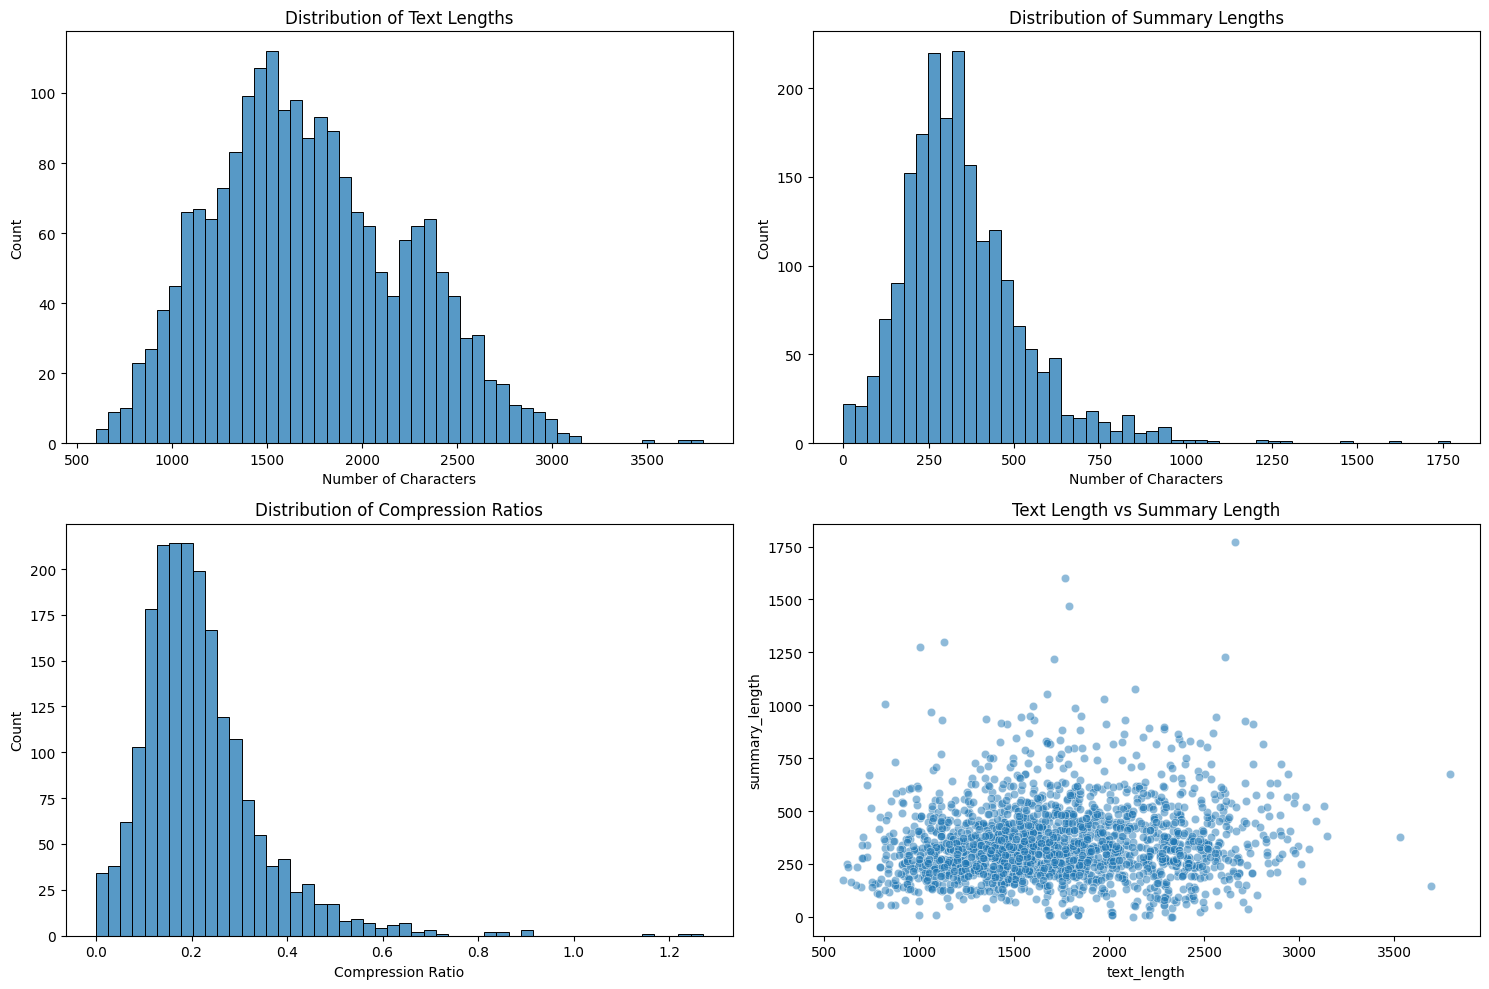

In [ ]:
print("\nLength Analysis:")
print("-" * 50)
length_stats = text_length_analysis(cleaned_ds_train)

In [ ]:
print(length_stats)

       text_length  summary_length   text_words  summary_words  \
count  2000.000000     2000.000000  2000.000000    2000.000000   
mean   1725.396500      350.144500   268.570500      54.753500   
std     506.904987      180.506008    78.913539      27.920038   
min     598.000000        0.000000    95.000000       0.000000   
25%    1360.750000      236.000000   210.750000      37.000000   
50%    1670.000000      322.000000   259.000000      50.000000   
75%    2079.000000      432.000000   321.000000      67.000000   
max    3792.000000     1769.000000   582.000000     259.000000   

       compression_ratio  
count        2000.000000  
mean            0.218386  
std             0.126498  
min             0.000000  
25%             0.137350  
50%             0.196037  
75%             0.270567  
max             1.270459  


Original Text Lengths:

- Most texts are between 1000-2500 characters
- The distribution peaks around 1500-1700 characters
- Mean text length is 1,726 characters
- There's a right-skewed distribution, with some texts extending to 3500+ characters

Summary Lengths:

- Summaries typically range from 100-750 characters
- Peak distribution is around 250-300 characters
- Mean summary length is 350 characters
- Shows a right-skewed distribution with some outliers up to 1750 characters

Compression Ratios:

- Most compression ratios fall between 0.1-0.4
- Mean compression ratio is 0.218 (meaning summaries are typically ~22% the length of original text)
- The distribution peaks around 0.2
- Some outliers show ratios above 1.0 (where summaries are longer than original texts)

Text vs Summary Length Correlation:

- Shows a positive but scattered correlation
- As text length increases, summary length tends to increase, but with high variance
- There's considerable spread in summary lengths for any given text length
Some notable outliers where summaries are unusually long relative to text length

Word Counts:

- Original texts average 269 words
- Summaries average 55 words
- The middle 50% of texts contain between 211-321 words
- The middle 50% of summaries contain between 37-67 words

This suggests that while there's a general relationship between text and summary lengths, the summarization process isn't strictly proportional, and there's significant variation in how much compression occurs across different texts.

### Sentence Analysis


Sentence Analysis:
--------------------------------------------------


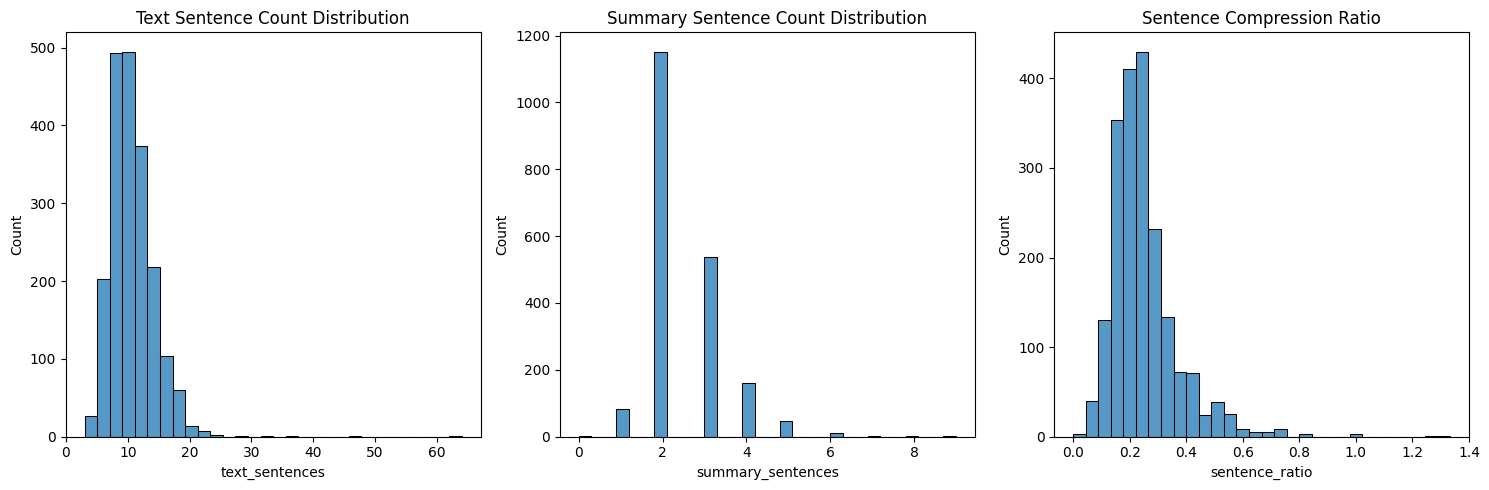

In [ ]:
print("\nSentence Analysis:")
print("-" * 50)
sentence_stats = sentence_analysis(cleaned_ds_train)

In [ ]:
print(sentence_stats)

       text_sentences  summary_sentences  sentence_ratio
count     2000.000000        2000.000000     2000.000000
mean        11.062500           2.496500        0.246160
std          3.593891           0.893525        0.119079
min          3.000000           0.000000        0.000000
25%          9.000000           2.000000        0.166667
50%         11.000000           2.000000        0.222222
75%         13.000000           3.000000        0.285714
max         64.000000           9.000000        1.333333


Text Sentence Distribution:

- Most texts contain between 5-20 sentences
- The distribution peaks around 8-12 sentences
- Mean is approximately 10.3 sentences per text
- There's a right-skewed distribution with some outliers having up to 63 sentences
- 50% of texts have between 8-12 sentences (IQR)

Summary Sentence Distribution:

- Very concentrated distribution
- Most summaries contain 2-4 sentences
- The most common is 3 sentences
- Mean is about 2.5 sentences
- Maximum is 9 sentences
- Almost no summaries have more than 6 sentences
- 50% of summaries have 2-3 sentences (IQR)

Sentence Compression Ratio:

- Mean ratio is 0.269 (summaries use about 27% of the original sentence count)
- Median ratio is 0.235 (slightly lower than mean, indicating some high outliers)
- Distribution peaks around 0.25-0.35
- Most ratios fall between 0.18 and 0.33 (25th to 75th percentile)
- Some extreme cases show ratios up to 2.0 (where summaries have more sentences than original text)
- Very few cases have ratios above 0.75

This shows that the summarization process tends to be fairly consistent in producing summaries of 2-3 sentences regardless of the original text length, though there is some scaling with longer texts. **The compression is quite aggressive**, typically reducing the number of sentences by about 75%. This is more extreme than the character/word-level compression we saw in the previous graphs, suggesting that **summarization involves combining information from multiple original sentences into single summary sentences**.


### Vocabulary Analysis


Vocabulary Analysis:
--------------------------------------------------


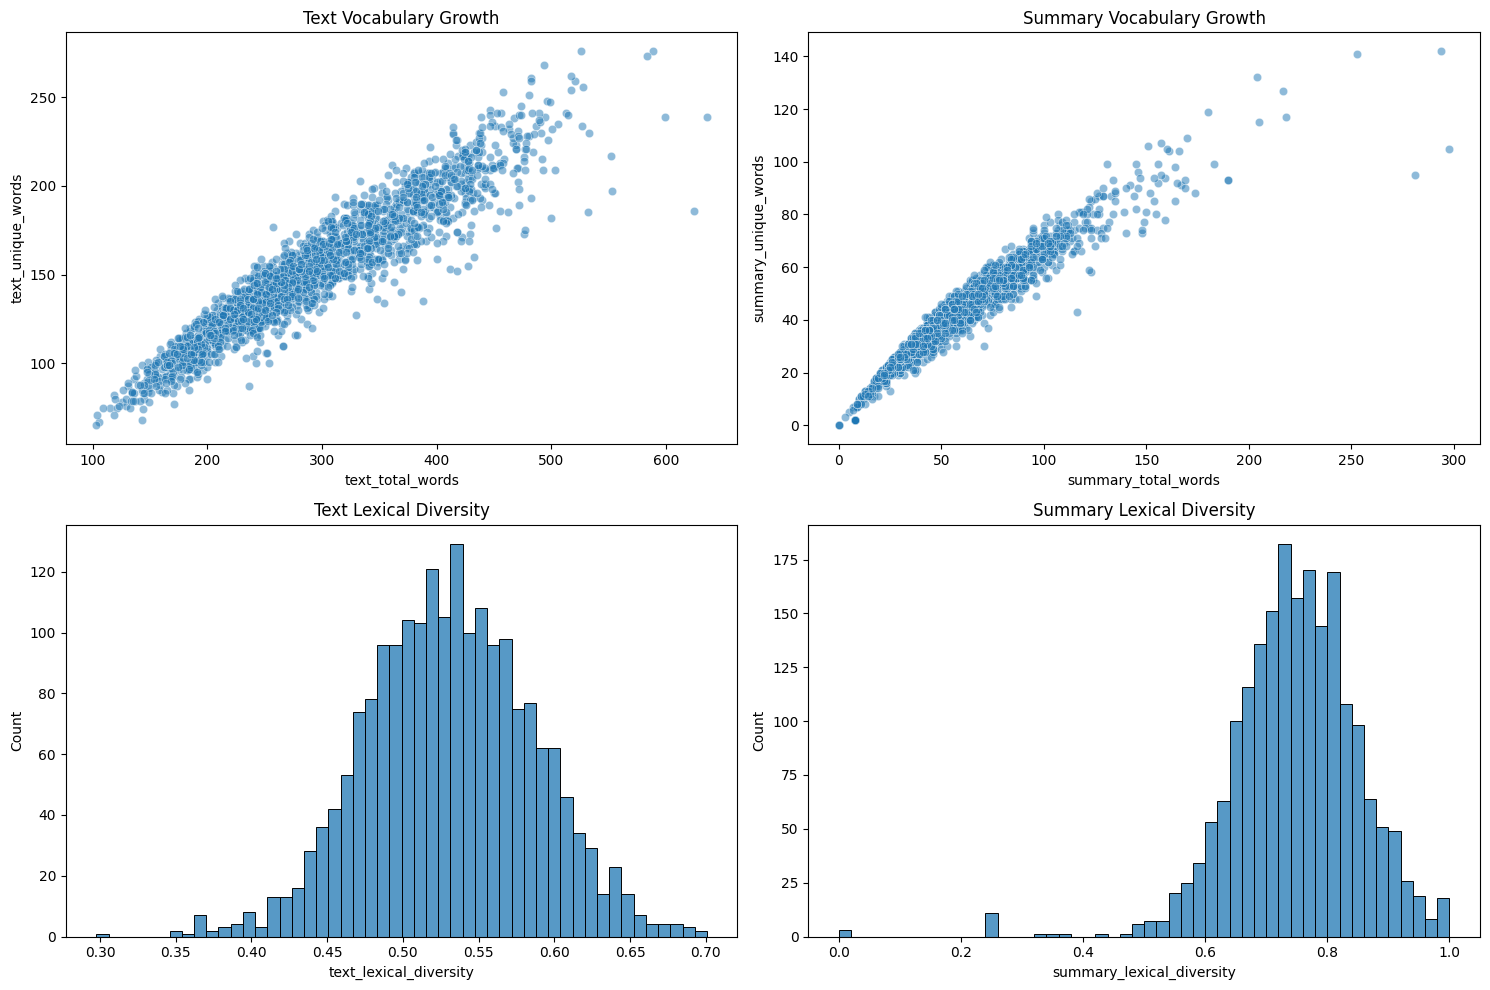

In [ ]:
print("\nVocabulary Analysis:")
print("-" * 50)
vocab_stats = vocabulary_analysis(cleaned_ds_train)

In [ ]:
print(vocab_stats)

       text_unique_words  text_total_words  text_lexical_diversity  \
count         2000.00000       2000.000000             2000.000000   
mean           152.34150        293.200000                0.530735   
std             36.51036         87.021195                0.055489   
min             65.00000        103.000000                0.297600   
25%            125.00000        230.000000                0.492590   
50%            149.00000        283.000000                0.530639   
75%            176.25000        352.000000                0.567172   
max            276.00000        636.000000                0.700730   

       summary_unique_words  summary_total_words  summary_lexical_diversity  
count           2000.000000          2000.000000                2000.000000  
mean              43.388000            60.422500                   0.746873  
std               17.499759            30.768252                   0.104901  
min                0.000000             0.000000         

Vocabulary Growth (Text):
-
- Strong linear relationship between total words and unique words
- As text length increases from 100 to 600 words, unique words increase from ~75 to ~250
- Shows diminishing returns: the rate of new word introduction slows as texts get longer
- Clear positive correlation but with some scatter, indicating variation in writing styles

Vocabulary Growth (Summary):

- Similar linear relationship but at a smaller scale
- Summaries range from ~0 to 300 total words
- Unique words range from ~0 to 140
- Very tight correlation at lower word counts, more variance at higher counts
- More consistent relationship than in full texts

Lexical Diversity (Text):

- Measured as ratio of unique words to total words
- Centered around 0.5-0.6 (50-60% of words are unique)
- Normal-like distribution with slight right skew
- Most texts fall between 0.45-0.65 lexical diversity
- Very few texts below 0.3 or above 0.7

Lexical Diversity (Summary):

- Higher lexical diversity than original texts
- Centered around 0.7-0.8 (70-80% of words are unique)
- More right-skewed distribution
- Most summaries fall between 0.6-0.9 lexical diversity
- Some summaries reach near 1.0 (almost all words unique)

This suggests that:

- Summaries tend to be more lexically dense than original texts
- They use a higher proportion of unique words
- They likely focus on key terms and minimize repetition
- The summarization process appears to prioritize information-dense vocabulary
- Short summaries especially tend to use almost entirely unique words to maximize information content

These patterns indicate that the summarization process isn't just about reducing length, but also about optimizing language efficiency and information density.

## General Text Analysis

The Analysis above suggest that the summarization of text is a very compressive summarization with typically reducing the number of sentences by 75%. This is done by using a higher proportion of unique words to increase the denseness of information and optimizing language efficiency in the summary text. Which resulted in the dataset more suitable to **Abstactive Summarization Method**

## Word Cloud

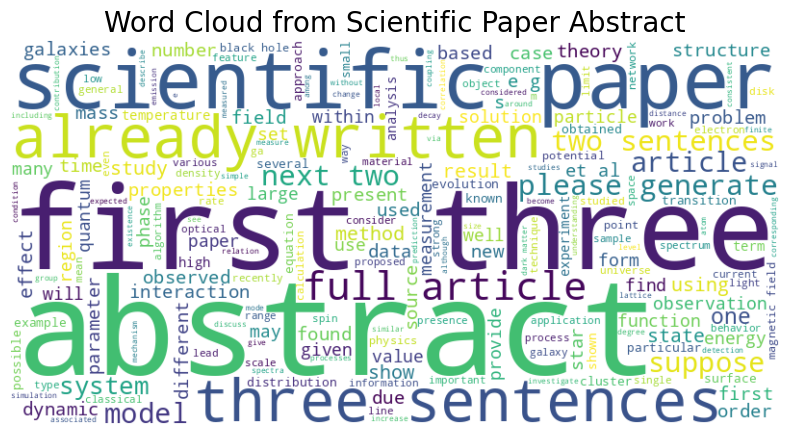

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Combine cleaned text
combined_text = ""
for entry in cleaned_ds_train:
    combined_text += entry['input'] + " " + entry['output'] + " "

for entry in cleaned_ds_val:
    combined_text += entry['input'] + " " + entry['output'] + " "

for entry in cleaned_ds_test:
    combined_text += entry['input'] + " " + entry['output'] + " "

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(combined_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axis
plt.title('Word Cloud from Scientific Paper Abstract', fontsize=20)
plt.show()

###Word Cloud Analysis

In the word cloud above, there are words like "scientific," "paper," "abstract," "first," "three," and "sentences" appear large and frequent in the word cloud, indicating that they are common throughout the dataset. Moreover, there are also presence of words like "please," "generate," "provide," and "written". This suggests that the dataset contains repetitive structures or instructions, likely due to the prompts or instruction-based requests, possibly asking for the generation of specific sections of text, such as the next few sentences of an article. This suggests that the dataset not only contains scientific content but also interactive or instructional elements, further complicating the summarization process.

Thus, below is a wordcloud for which has been cleaned from those prompts.

In [ ]:
# Cleaning for word cloud

import re

# Function to remove all text before and including the first colon only
def word_cloud_preprocessing(article):
    # Use regex to remove everything before and including the first colon, leaving other colons untouched
    article['input'] = re.sub(r'^[^:]*:\s*', '', article['input'], count=1)

    # Remove the phrases
    article['input'] = re.sub(r'please generate the next two sentences of the article', '', article['input'], flags=re.IGNORECASE)
    article['input'] = re.sub(r'and you have already written the first three sentences of the full article:', '', article['input'], flags=re.IGNORECASE)

    return article

# Apply the function to all items in the dataset
word_cloud_data_train = [word_cloud_preprocessing(article) for article in cleaned_ds_train]
word_cloud_data_test = [word_cloud_preprocessing(article) for article in cleaned_ds_test]
word_cloud_data_val = [word_cloud_preprocessing(article) for article in cleaned_ds_val]

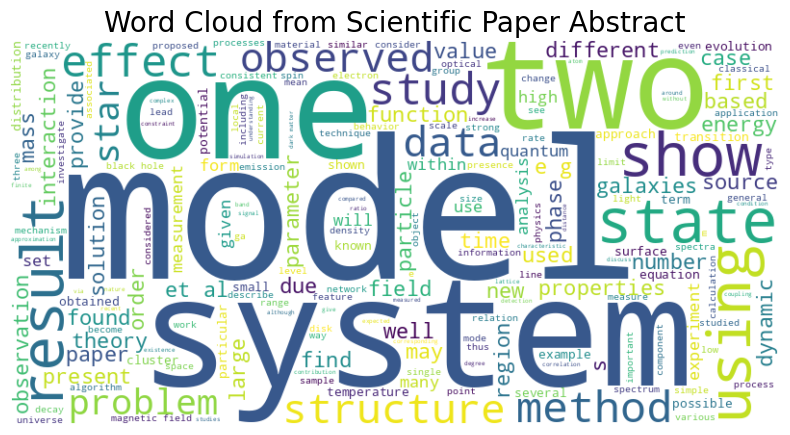

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Combine cleaned text
combined_text = ""
for entry in word_cloud_data_train:
    combined_text += entry['input'] + " " + entry['output'] + " "

for entry in word_cloud_data_val:
    combined_text += entry['input'] + " " + entry['output'] + " "

for entry in word_cloud_data_test:
    combined_text += entry['input'] + " " + entry['output'] + " "

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(combined_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axis
plt.title('Word Cloud from Scientific Paper Abstract', fontsize=20)
plt.show()

### Word Cloud Analysis
After cleaning the dataset from prompts, we can see more of the datasets' topic. Starting from the most prominent words, such as "system," "model," "properties," "effect," "structure," "data," and "method," indicate that the dataset heavily features discussions on modeling systems, exploring their properties, and understanding the effects of various factors. Additionally, words like "structure," "study," and "result" suggest that many abstracts focus on analyzing structures and summarizing the outcomes of different studies.

The dataset also contains a significant amount of quantitative and methodological vocabulary, including terms such as "data," "method," "analysis," "model," and "theory." This indicates that the papers follow a structured approach typical of scientific writing, where methods and models play a central role. Words like "dynamic," "using," and "observed" frequently appear, reflecting the way these processes or results are often described.

Specific scientific topics are also present, with terms like "star," "quantum," and "galaxies" suggesting that some papers in the dataset relate to astronomy or physics. Other terms, such as "temperature," "field," and "interaction," suggest a focus on physical properties, likely within various scientific domains such as thermodynamics or material science.

The word cloud further reveals an emphasis on problem-solving and observations, as seen with terms like "problem," "observed," "effect," and "study." This implies that many papers address specific issues through observational or experimental studies, highlighting the dataset’s focus on a data-driven and experimental approach. This is a critical aspect for the summarization model to accurately capture.

Additionally, terms like "theory," "solution," "distribution," and "value" indicate that the papers frequently explore analytical and theoretical aspects, emphasizing the quantitative nature of the analysis. This highlights the need for the model to be capable of handling domain-specific terminology and presenting it concisely.

## TF-IDF to Check for word Importance

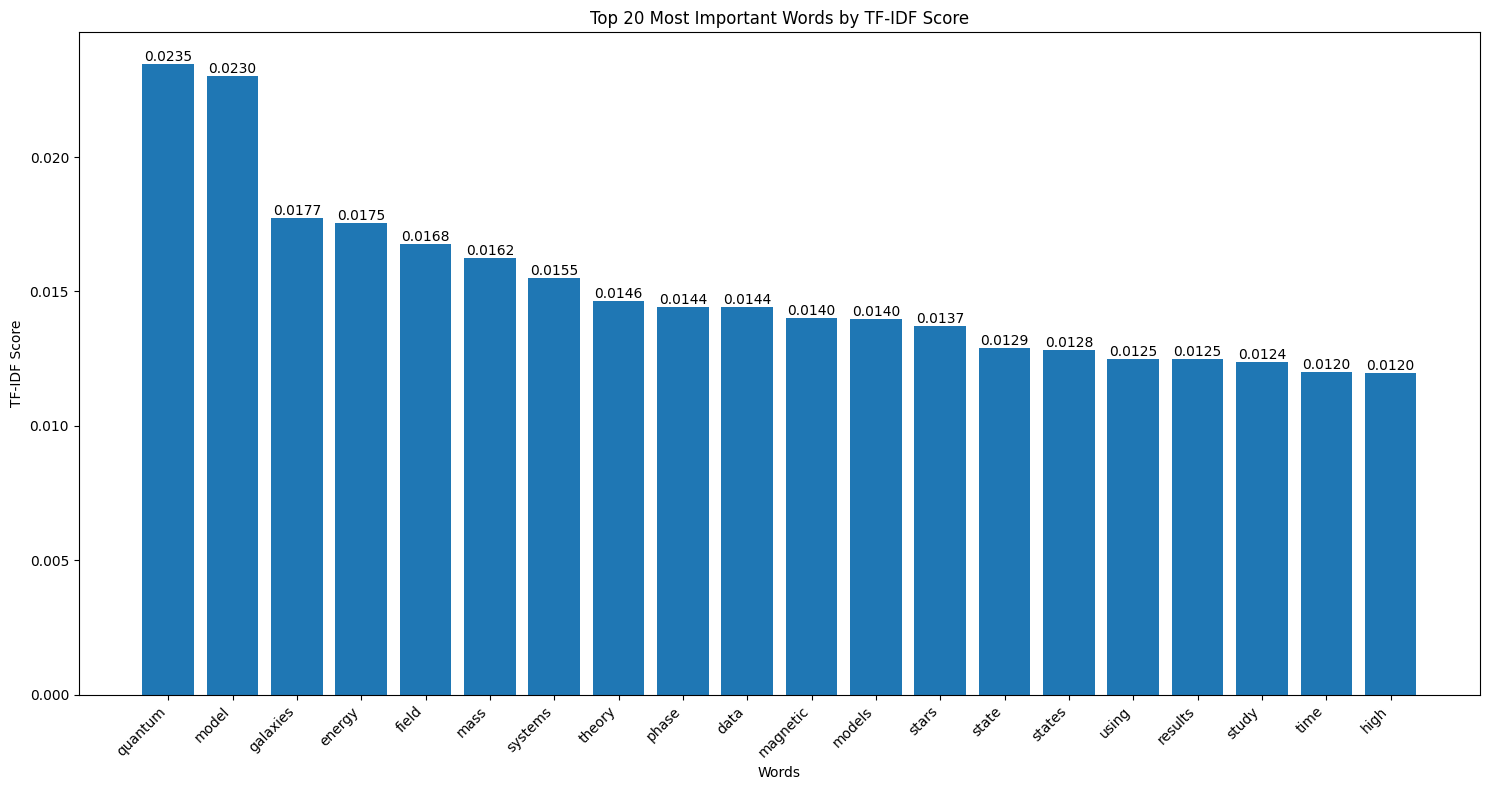


Top 20 words and their TF-IDF scores:
quantum: 0.0235
model: 0.0230
galaxies: 0.0177
energy: 0.0175
field: 0.0168
mass: 0.0162
systems: 0.0155
theory: 0.0146
phase: 0.0144
data: 0.0144
magnetic: 0.0140
models: 0.0140
stars: 0.0137
state: 0.0129
states: 0.0128
using: 0.0125
results: 0.0125
study: 0.0124
time: 0.0120
high: 0.0120


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import matplotlib.pyplot as plt

# Create a TfidfVectorizer with proper preprocessing
vectorizer = TfidfVectorizer(
    stop_words='english',  # Remove English stopwords
    max_features=5000,     # Limit to top 5000 terms
    min_df=5,             # Remove terms that appear in less than 5 documents
    max_df=0.95,          # Remove terms that appear in more than 95% of documents
)

# Fit and transform the documents
tfidf_matrix = vectorizer.fit_transform(cleaned_ds_train['input'])

# Get feature names and their TF-IDF scores
feature_names = vectorizer.get_feature_names_out()
tfidf_scores = np.array(tfidf_matrix.mean(axis=0)).flatten()

# Create a dictionary of words and their scores
word_scores = dict(zip(feature_names, tfidf_scores))

# Sort words by TF-IDF score in descending order and get top 20
top_n = 20
top_words = dict(sorted(word_scores.items(), key=lambda x: x[1], reverse=True)[:top_n])

# Create the plot
plt.figure(figsize=(15, 8))
bars = plt.bar(range(len(top_words)), list(top_words.values()))
plt.xticks(range(len(top_words)), list(top_words.keys()), rotation=45, ha='right')
plt.title('Top 20 Most Important Words by TF-IDF Score')
plt.xlabel('Words')
plt.ylabel('TF-IDF Score')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print the top words and their scores
print("\nTop 20 words and their TF-IDF scores:")
for word, score in top_words.items():
    print(f"{word}: {score:.4f}")

From the TF-IDF score result, it can be seen that the dataset consist of mostly scientific papers, with a focus on Physics, Astrology, and Material Sciences. It can also be seen that from the high value of 'models' and 'theory' the papers in the dataset mostly use computational approaches.

# Model

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        # Ensure that the model dimension (d_model) is divisible by the number of heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        # Initialize dimensions
        self.d_model = d_model # Model's dimension
        self.num_heads = num_heads # Number of attention heads
        self.d_k = d_model // num_heads # Dimension of each head's key, query, and value

        # Linear layers for transforming inputs
        self.W_q = nn.Linear(d_model, d_model) # Query transformation
        self.W_k = nn.Linear(d_model, d_model) # Key transformation
        self.W_v = nn.Linear(d_model, d_model) # Value transformation
        self.W_o = nn.Linear(d_model, d_model) # Output transformation

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Calculate attention scores
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Apply mask if provided (useful for preventing attention to certain parts like padding)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)

        # Softmax is applied to obtain attention probabilities
        attn_probs = torch.softmax(attn_scores, dim=-1)

        # Multiply by values to obtain the final output
        output = torch.matmul(attn_probs, V)
        return output

    def split_heads(self, x):
        # Reshape the input to have num_heads for multi-head attention
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        # Combine the multiple heads back to original shape
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        # Apply linear transformations and split heads
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        # Perform scaled dot-product attention
        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)

        # Combine heads and apply output transformation
        output = self.W_o(self.combine_heads(attn_output))
        return output

In [ ]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()

        # Create a tensor filled with zeros, which will be populated with positional encodings.
        pe = torch.zeros(max_seq_length, d_model)

        # Create a A tensor containing the position indices for each position in the sequence.
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)

        #  A term used to scale the position indices in a specific way.
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x

In [ ]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout):
        super(Transformer, self).__init__()
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, src, tgt):
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2).to(src.device)
        tgt_mask = (tgt != 0).unsqueeze(1).unsqueeze(3).to(tgt.device)
        seq_length = tgt.size(1)
        nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length, device=tgt.device), diagonal=1)).bool()
        tgt_mask = tgt_mask & nopeak_mask
        return src_mask, tgt_mask

    def forward(self, src, tgt):
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(tgt)))

        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, src_mask)

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask)

        output = self.fc(dec_output)
        return output

In [ ]:
from transformers import BertTokenizer
import numpy as np

# Initialize the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print('Tokenizer Loaded')

# Tokenize the sentences and pad/truncate to the same length
# Set max sequence length to the mean word length in the list of string
max_seq_length = int(np.mean([len(sentence.split()) for sentence in ds_train['input']]))

# Print the maximum sequence length
print(f"Max Sequence Length: {max_seq_length}")

tokenized_train_src = tokenizer(ds_train['input'], return_tensors='pt', padding=True, truncation=True, max_length=max_seq_length)
print('Tokenized Train Input')

tokenized_train_tgt = tokenizer(ds_train['output'], return_tensors='pt', padding=True, truncation=True, max_length=max_seq_length)
print('Tokenized Train Output')

tokenized_val_src = tokenizer(ds_val['input'], return_tensors='pt', padding=True, truncation=True, max_length=max_seq_length)
print('Tokenized Val Input')

tokenized_val_tgt = tokenizer(ds_val['output'], return_tensors='pt', padding=True, truncation=True, max_length=max_seq_length)
print('Tokenized Val Output')

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Tokenizer Loaded
Max Sequence Length: 317
Tokenized Train Input
Tokenized Train Output
Tokenized Val Input
Tokenized Val Output


In [ ]:
# Extract input IDs (tokenized data) and attention masks
train_src_data = tokenized_train_src['input_ids']  # Token IDs for the source (input sentences)

train_tgt_data = tokenized_train_tgt['input_ids']  # Token IDs for the target (same as source for this example)

val_src_data = tokenized_val_src['input_ids']  # Token IDs for the source (input sentences)

val_tgt_data = tokenized_val_tgt['input_ids']  # Token IDs for the target (same as source for this example)

# Check tensor shape
print(f"train_src_data shape: {train_src_data.shape}")
print(f"train_tgt_data shape: {train_tgt_data.shape}")

# Check tensor shape
print(f"val_src_data shape: {val_src_data.shape}")
print(f"val_tgt_data shape: {val_tgt_data.shape}")

train_src_data shape: torch.Size([2000, 317])
train_tgt_data shape: torch.Size([2000, 317])
val_src_data shape: torch.Size([200, 317])
val_tgt_data shape: torch.Size([200, 268])


In [ ]:
# Create Batched dataset
batch_size = 32
dataset = data.TensorDataset(train_src_data, train_tgt_data)
dataloader = data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

val_dataset = data.TensorDataset(val_src_data, val_tgt_data)
val_dataloader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# Hyperparameters (example values)
src_vocab_size = tokenizer.vocab_size  # Use the vocab size from the tokenizer
tgt_vocab_size = tokenizer.vocab_size
d_model = 1024
num_heads = 8
num_layers = 4
d_ff = 2048
dropout = 0.1

# Transformer Model
transformer = Transformer(src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout)

num_epochs = 10  # Define number of epochs
criterion = torch.nn.CrossEntropyLoss()  # Loss function
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)  # Optimizer

In [ ]:
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

def train(model, train_dataloader, val_dataloader, optimizer, criterion, num_epochs, tgt_vocab_size):
    # Determine the device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Move model to the device
    model = model.to(device)

    def validate(model, val_dataloader, criterion):
        model.eval()
        total_loss = 0
        total_tokens = 0

        for batch in tqdm(val_dataloader, desc="Validating", leave=False):
            src_data, tgt_data = batch
            src_data, tgt_data = src_data.to(device), tgt_data.to(device)
            with torch.no_grad():
                output = model(src_data, tgt_data[:, :-1])
                output = output.contiguous().view(-1, tgt_vocab_size)
                tgt_data_shifted = tgt_data[:, 1:].contiguous().view(-1)

                loss = criterion(output, tgt_data_shifted)

                total_loss += loss.item() * tgt_data_shifted.size(0)
                total_tokens += tgt_data_shifted.size(0)

        avg_loss = total_loss / total_tokens
        return avg_loss

    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss = 0
        train_tokens = 0
        train_progress_bar = tqdm(train_dataloader, desc=f"Training Epoch {epoch+1}/{num_epochs}", leave=False)
        for batch in train_progress_bar:
            src_data, tgt_data = batch
            src_data, tgt_data = src_data.to(device), tgt_data.to(device)

            optimizer.zero_grad()
            output = model(src_data, tgt_data[:, :-1])

            output = output.contiguous().view(-1, tgt_vocab_size)
            tgt_data_shifted = tgt_data[:, 1:].contiguous().view(-1)

            loss = criterion(output, tgt_data_shifted)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * tgt_data_shifted.size(0)
            train_tokens += tgt_data_shifted.size(0)

            train_progress_bar.set_postfix({"Train Loss": train_loss / train_tokens})

        avg_train_loss = train_loss / train_tokens

        # Validate
        val_loss = validate(model, val_dataloader, criterion)

        print(f"Epoch: {epoch+1}/{num_epochs}")
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Validation Loss: {val_loss:.4f}")

    return model

# Usage example:
# trained_model = train(transformer, train_dataloader, val_dataloader, optimizer, criterion, num_epochs, tgt_vocab_size)

In [ ]:
trained_model = train(transformer, dataloader, val_dataloader, optimizer, criterion, 100, tgt_vocab_size)

Using device: cuda


Training Epoch 1/100:   0%|          | 0/63 [00:00<?, ?it/s]

Validating:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 1/100
Train Loss: 1.3152
Validation Loss: 1.6049


Training Epoch 2/100:   0%|          | 0/63 [00:00<?, ?it/s]

...

Training Epoch 6/100:   0%|          | 0/63 [00:00<?, ?it/s]

Validating:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 6/100
Train Loss: 1.0545
Validation Loss: 1.5499


Training Epoch 7/100:   0%|          | 0/63 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Initialize the tokenizer (use the same tokenizer as during training)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

model = transformer

# Define the function for inference with a start token
def inference(model, input_sentence, max_seq_length):
    # Step 1: Tokenize the input sentence
    tokenized_input = tokenizer(input_sentence, return_tensors='pt', padding=True, truncation=True, max_length=max_seq_length)

    # Step 2: Extract input_ids and prepare for model input
    src_input = tokenized_input['input_ids'].to("cuda")

    # Step 3: Create a tensor to start the generation process
    tgt_input = torch.full((1, 1), tokenizer.cls_token_id, dtype=torch.long).to("cuda")

    # Step 4: Perform iterative generation of output tokens (greedy decoding)
    generated_tokens = []
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        for _ in range(max_seq_length):
            # Forward pass through the model
            output = model(src_input, tgt_input)

            # Get the token with the highest probability
            next_token = torch.argmax(output[:, -1, :], dim=-1).unsqueeze(0)

            # Print all token probability with it's decoded word
            # generated_word = tokenizer.decode(next_token[0], skip_special_tokens=False)
            # print(f"Generated Word: {generated_word}")

            # Append the predicted token to the generated sequence
            generated_tokens.append(next_token.item())

            # Break if <EOS> (end of sentence) token is generated
            if next_token.item() == tokenizer.sep_token_id:  # SEP token is used for <EOS> in BERT
                break

            # Update target input with the new predicted token
            tgt_input = torch.cat((tgt_input, next_token), dim=1)

    # Step 5: Decode the generated tokens to a sentence
    predicted_sentence = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    return predicted_sentence

# Example input sentence
input_sentence = "suppose that you have an abstract for a scientific paper: In recent years, diffusion-based text-to-music (TTM) generation has gained prominence, offering an innovative approach to synthesizing musical content from textual descriptions. Achieving high accuracy and diversity in this generation process requires extensive, high-quality data, including both high-fidelity audio waveforms and detailed text descriptions, which often constitute only a small portion of available datasets. In open-source datasets, issues such as low-quality music waveforms, mislabeling, weak labeling, and unlabeled data significantly hinder the development of music generation models. To address these challenges, we propose a novel paradigm for high-quality music generation that incorporates a quality-aware training strategy, enabling generative models to discern the quality of input music waveforms during training. Leveraging the unique properties of musical signals, we first adapted and implemented a masked diffusion transformer (MDT) model for the TTM task, demonstrating its distinct capacity for quality control and enhanced musicality. Additionally, we address the issue of low-quality captions in TTM with a caption refinement data processing approach. Experiments demonstrate our state-of-the-art (SOTA) performance on MusicCaps and the Song-Describer Dataset. Our demo page can be accessed at"

# Call the inference function
predicted_output = inference(model, input_sentence, max_seq_length=max_seq_length)

# Display the prediction
print(f"Input: {input_sentence}")
print(f"Predicted Output: {predicted_output}")

Input: suppose that you have an abstract for a scientific paper: In recent years, diffusion-based text-to-music (TTM) generation has gained prominence, offering an innovative approach to synthesizing musical content from textual descriptions. Achieving high accuracy and diversity in this generation process requires extensive, high-quality data, including both high-fidelity audio waveforms and detailed text descriptions, which often constitute only a small portion of available datasets. In open-source datasets, issues such as low-quality music waveforms, mislabeling, weak labeling, and unlabeled data significantly hinder the development of music generation models. To address these challenges, we propose a novel paradigm for high-quality music generation that incorporates a quality-aware training strategy, enabling generative models to discern the quality of input music waveforms during training. Leveraging the unique properties of musical signals, we first adapted and implemented a mask

In [ ]:
# Check number of parameter in the transformer model
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(transformer):,} trainable parameters')

The model has 177,794,874 trainable parameters
